# EMiF Project — Has the structure of risk in financial markets changed since COVID-19?

## Section 0 — Data loading and transformations

The goal of this section is to prepare a clean dataset that all subsequent sections will use without modification. Every transformation is documented and justified here.

This section produces the following objects:

- `prices` — daily prices, forward-filled, full sample, all 14 assets
- `yields` — daily level of the two rate series (US and German 10-year)
- `returns` — daily log-returns, full sample, 12 assets (rates excluded)
- `ret_pre` — log-returns, 2010–2020, main pre-COVID reference
- `ret_post` — log-returns, 2020–2026, post-COVID regime
- `ret_pre_full` — log-returns, 1990–2020, robustness checks only

### Why 2010–2020 as the pre-COVID reference period?

Taking everything before March 2020 as the pre-COVID period would include the Dot-com crash, 9/11 and the Global Financial Crisis, events that are themselves major structural breaks. A pre-COVID period that already contains three crises is not a meaningful benchmark for normality.

We instead use 2010–2020, a decade characterised by low interest rates, subdued volatility and a long equity bull market. This is the period investors and risk managers considered normal immediately before COVID. The full 1990–2020 sample is kept as `ret_pre_full` for robustness checks in the appendix.

### On the choice of breakpoint

We set the COVID breakpoint at 23 March 2020. This date corresponds to the S&P 500 market bottom and to the Federal Reserve announcement of unlimited quantitative easing. The VIX also peaked above 80 on that date, a level not reached since 2008. We are not studying the crash itself but the new risk regime that emerged after it, so the post-COVID period starts at the market low. Section 5 will test this choice statistically using the Bai-Perron procedure.

### 0.1 Libraries and global parameters

In [929]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH      = "Data.xlsx"
SHEET          = "Feuil1"
ANNUALIZATION  = 252
COVID_BREAK    = "2020-03-23"
PRE_START      = "2010-01-01"
PRE_START_FULL = "1990-01-01"

RATE_SERIES = ["US T 10-year Yield", "German Gov 10-year yield"]

CATEGORIES = {
    "Equities"    : ["S&P500", "Eurostoxx 50", "Hang Seng", "MSCI EM", "SMI"],
    "Commodities" : ["Oil futures", "Gold"],
    "FX"          : ["EURUSD", "USDJPY", "USDCHF"],
    "Credit"      : ["US IG Bonds", "US HY Bonds"]
}

COLORS = {
    "pre"  : "steelblue",
    "post" : "firebrick",
    "full" : "dimgray"
}

FIG_DIR = Path("Figures")
TAB_DIR = Path("Tables")
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "font.size"         : 11
})

### 0.2 Loading and cleaning the data

Missing values come from calendar mismatches between markets, US, European and Asian exchanges do not share the same holidays. The standard treatment is to forward-fill: the last observed price is carried forward until the next available observation, which is equivalent to assuming no trade and no new information on non-trading days.

Oil futures prices briefly turned negative in April 2020. Non-positive prices are treated as missing and forward-filled before computing log-returns.

Log-returns are defined as $r_{i,t} = \log(P_{i,t}) - \log(P_{i,t-1})$. They are preferred over simple returns because they are approximately stationary, time-additive and symmetric around zero, all properties required for ARCH and GARCH estimation.

Rate series are treated separately. The US and German 10-year yields are already expressed as rates, not prices. Computing log-differences on yields that approached zero as the German yield did between 2015 and 2020 produces values that are not economically meaningful. A yield moving from 0.10% to 0.05% generates a log-return of -69%, which bears no relationship to the actual market move. For this reason, rate series are stored separately as levels in `yields` and are used directly for visualisation and correlation analysis. They are not included in `returns`.

In [930]:
def load_data(path, sheet, rate_series, pre_start, pre_start_full, covid_break):

    raw = pd.read_excel(path, sheet_name=sheet, index_col=0, parse_dates=True)
    raw = raw.sort_index().ffill()

    missing_before = (raw.isnull().sum() / len(raw) * 100).round(1)

    yields  = raw[rate_series].copy()

    non_rate_cols = [c for c in raw.columns if c not in rate_series]
    prices_ = raw[non_rate_cols].where(raw[non_rate_cols] > 0).ffill().dropna()

    returns = np.log(prices_).diff().dropna()

    ret_pre = returns.loc[
        pre_start : pd.Timestamp(covid_break) - pd.Timedelta(days=1)
    ]
    ret_post     = returns.loc[covid_break:]
    ret_pre_full = returns.loc[
        pre_start_full : pd.Timestamp(covid_break) - pd.Timedelta(days=1)
    ]

    return raw, yields, returns, ret_pre, ret_post, ret_pre_full, missing_before


prices, yields, returns, ret_pre, ret_post, ret_pre_full, missing_before = load_data(
    DATA_PATH, SHEET, RATE_SERIES, PRE_START, PRE_START_FULL, COVID_BREAK
)

print(f"Full sample    : {returns.index.min().date()} to {returns.index.max().date()} ({len(returns):,} obs)")
print(f"Pre-COVID      : {ret_pre.index.min().date()} to {ret_pre.index.max().date()} ({len(ret_pre):,} obs)")
print(f"Post-COVID     : {ret_post.index.min().date()} to {ret_post.index.max().date()} ({len(ret_post):,} obs)")
print(f"Pre-COVID full : {ret_pre_full.index.min().date()} to {ret_pre_full.index.max().date()} ({len(ret_pre_full):,} obs)")
print(f"\nAssets in returns ({len(returns.columns)}): {list(returns.columns)}")
print(f"Rate series in yields ({len(yields.columns)}): {list(yields.columns)}")
print(f"\nGerman Gov yield — min: {yields['German Gov 10-year yield'].min():.4f}")
print(f"German Gov yield — nb negative: {(yields['German Gov 10-year yield'] < 0).sum()}")

Full sample    : 1990-01-04 to 2026-04-24 (9,597 obs)
Pre-COVID      : 2010-01-01 to 2020-03-20 (2,702 obs)
Post-COVID     : 2020-03-23 to 2026-04-24 (1,611 obs)
Pre-COVID full : 1990-01-04 to 2020-03-20 (7,986 obs)

Assets in returns (12): ['S&P500', 'Eurostoxx 50', 'Hang Seng', 'MSCI EM', 'SMI', 'Oil futures', 'Gold', 'EURUSD', 'USDJPY', 'US IG Bonds', 'US HY Bonds', 'USDCHF']
Rate series in yields (2): ['US T 10-year Yield', 'German Gov 10-year yield']

German Gov yield — min: -0.8556
German Gov yield — nb negative: 813


### 0.3 Dataset overview

In [931]:
print("Missing values before treatment (%):\n")
print(missing_before.to_string())
missing_before.to_csv(TAB_DIR / "tab0_missing_values.csv")

Missing values before treatment (%):

S&P500                      0.0
Eurostoxx 50                0.0
Hang Seng                   0.0
MSCI EM                     0.0
SMI                         0.0
US T 10-year Yield          0.0
German Gov 10-year yield    0.0
Oil futures                 0.0
Gold                        0.0
EURUSD                      0.0
USDJPY                      0.0
US IG Bonds                 0.0
US HY Bonds                 0.0
USDCHF                      0.0


In [932]:
print("Assets in returns:\n")
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    print(f"  {cat:15}: {', '.join(available)}")

print(f"\nRate series (stored as levels in yields):")
for r in RATE_SERIES:
    print(f"  {r}")

Assets in returns:

  Equities       : S&P500, Eurostoxx 50, Hang Seng, MSCI EM, SMI
  Commodities    : Oil futures, Gold
  FX             : EURUSD, USDJPY, USDCHF
  Credit         : US IG Bonds, US HY Bonds

Rate series (stored as levels in yields):
  US T 10-year Yield
  German Gov 10-year yield


### 0.4 Cumulative returns and yield levels

The following charts give a first visual overview of the full sample since 1990. Each panel covers one asset class. The vertical dashed line marks the COVID breakpoint at 23 March 2020. Rate series are displayed as yield levels rather than cumulative returns, which is the economically meaningful representation for interest rates.

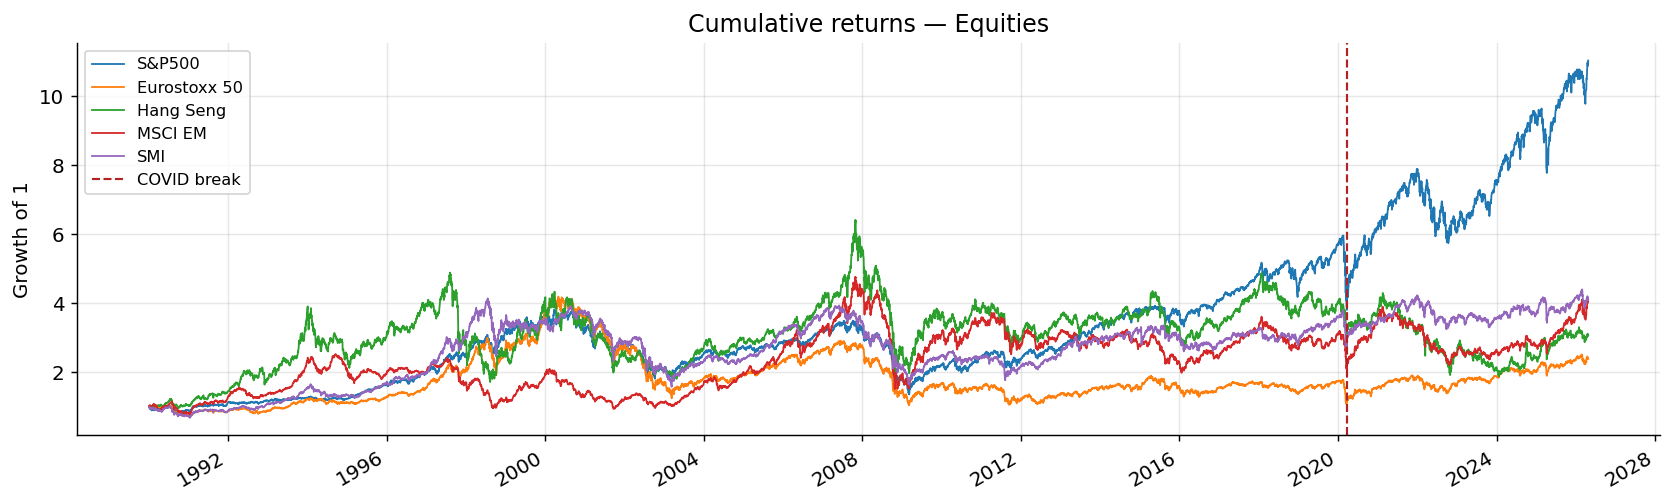

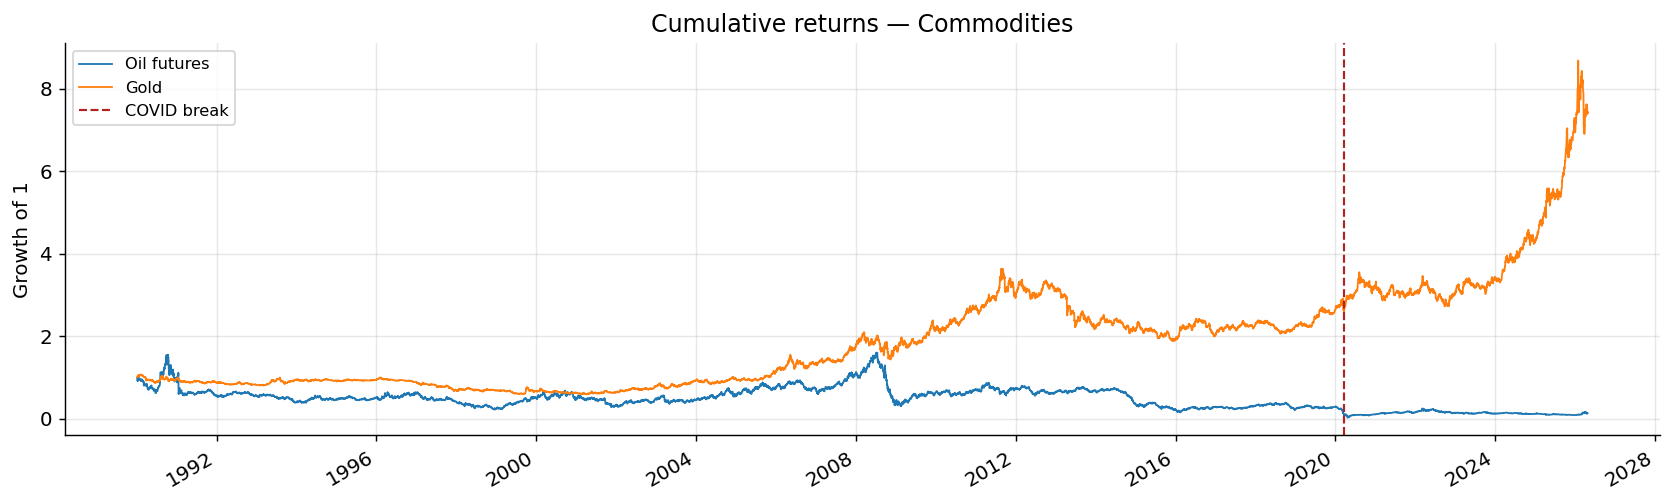

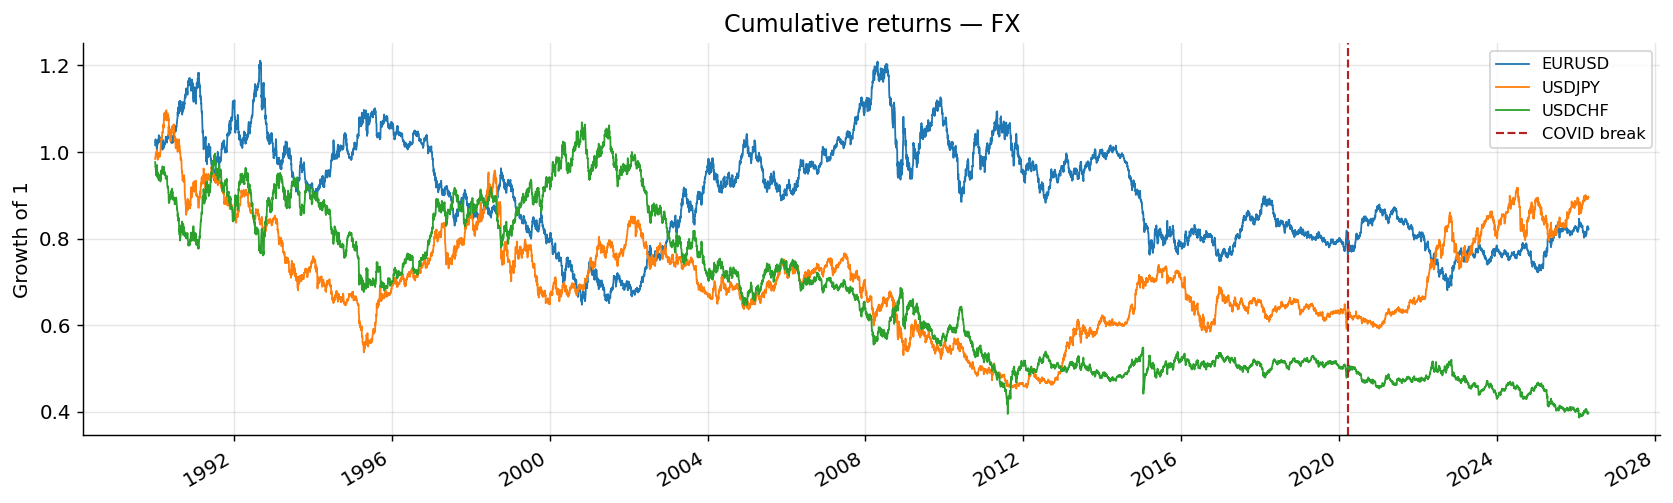

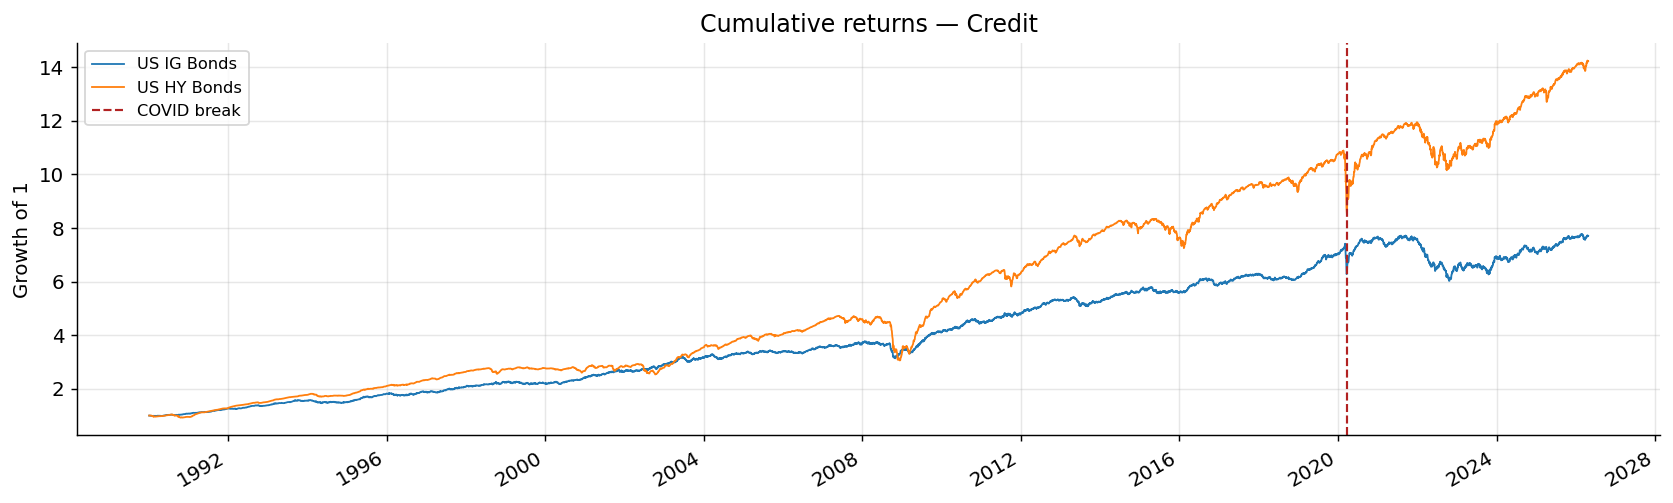

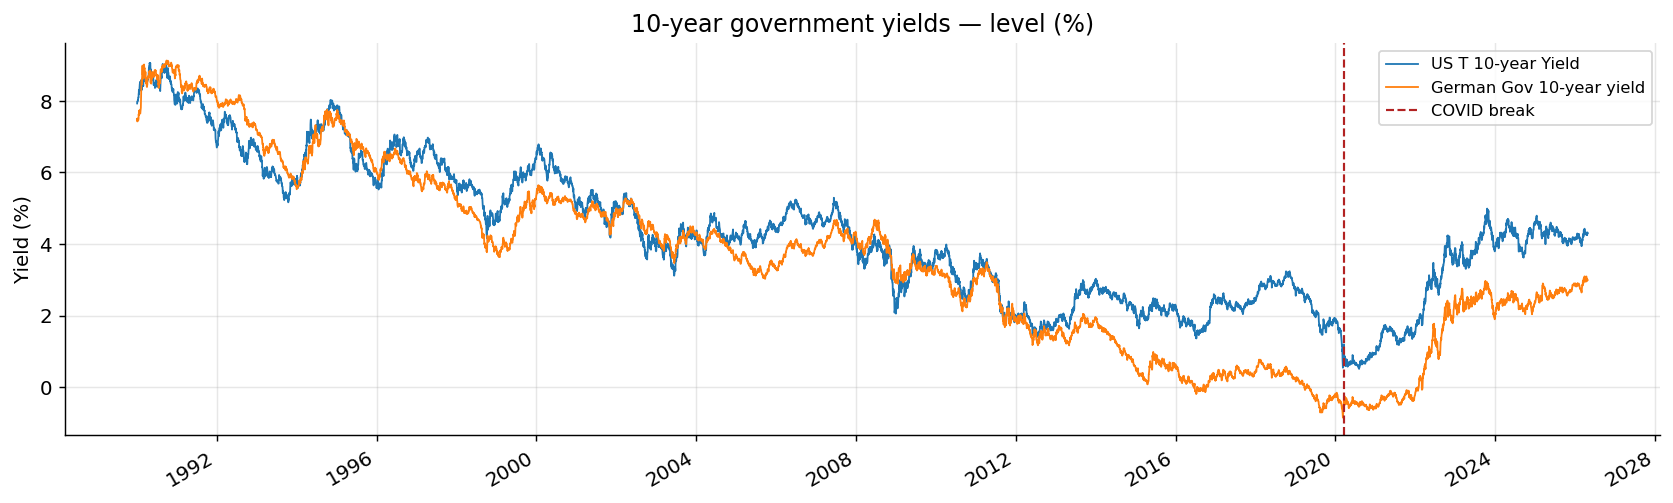

In [933]:
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    cum = (1 + returns[available]).cumprod()

    fig, ax = plt.subplots(figsize=(13, 4))
    cum.plot(ax=ax, linewidth=1)
    ax.axvline(pd.Timestamp(COVID_BREAK), color="firebrick",
               linestyle="--", linewidth=1.2, label="COVID break")
    ax.set_title(f"Cumulative returns — {cat}")
    ax.set_ylabel("Growth of 1")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig0_cumret_{cat.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
yields.plot(ax=ax, linewidth=1)
ax.axvline(pd.Timestamp(COVID_BREAK), color="firebrick",
           linestyle="--", linewidth=1.2, label="COVID break")
ax.set_title("10-year government yields — level (%)")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_yields_level.png", dpi=150, bbox_inches="tight")
plt.show()

### 0.5 Descriptive statistics

Before running any model, we compare the first four moments of each return series across the two periods. Annualised volatility measures the level of risk. Skewness measures asymmetry and left-tail exposure. Excess kurtosis measures tail thickness relative to a Gaussian distribution. The minimum daily return captures the worst tail event in each period.

In [934]:
def desc_stats(ret):
    return pd.DataFrame({
        "Ann. Vol (%)"   : (ret.std() * np.sqrt(ANNUALIZATION) * 100).round(2),
        "Skewness"       : ret.apply(stats.skew).round(3),
        "Kurt. (excess)" : ret.apply(stats.kurtosis).round(3),
        "Min return (%)" : (ret.min() * 100).round(2),
    })

combined = pd.concat(
    [desc_stats(ret_pre), desc_stats(ret_post)],
    axis=1,
    keys=["Pre-COVID (2010-2020)", "Post-COVID (2020-2026)"]
)
combined.to_csv(TAB_DIR / "tab0_descriptive_stats.csv")
combined

Pre-COVID (2010-2020)                                         \
                      Ann. Vol (%) Skewness Kurt. (excess) Min return (%)   
S&P500                       16.29   -1.358         19.204         -12.77   
Eurostoxx 50                 20.12   -0.747          9.275         -13.24   
Hang Seng                    17.72   -0.336          2.724          -6.02   
MSCI EM                      15.68   -0.695          4.744          -6.94   
SMI                          15.17   -1.112         10.911         -10.13   
Oil futures                  35.51   -1.169         23.672         -28.22   
Gold                         15.10   -0.648          6.430          -9.51   
EURUSD                        8.73   -0.026          1.891          -2.41   
USDJPY                        9.06   -0.018          5.118          -3.78   
US IG Bonds                   4.49   -1.904         18.531          -3.83   
US HY Bonds                   4.32   -4.323         49.492          -3.68   
USDCHF                       11.10   -7.104        229.310         -19.38   

             Post-COVID (2020-2026)                                         
                       Ann. Vol (%) Skewness Kurt. (excess) Min return (%)  
S&P500                        17.86    0.320          8.199          -6.16  
Eurostoxx 50                  18.38    0.176          5.479          -5.09  
Hang Seng                     23.82   -0.373          7.872         -14.18  
MSCI EM                       16.68   -0.263          5.066          -8.25  
SMI                           13.97   -0.310          6.212          -5.52  
Oil futures                   52.89   -3.141         78.893         -60.17  
Gold                          17.20   -0.667          6.606          -9.37  
EURUSD                         7.33    0.219          1.547          -1.86  
USDJPY                         9.13   -0.565          4.020          -3.86  
US IG Bonds                    5.88    0.083          1.933          -1.80  
US HY Bonds                    5.31    0.882         16.096          -2.39  
USDCHF                         7.76   -0.689          4.448          -3.91

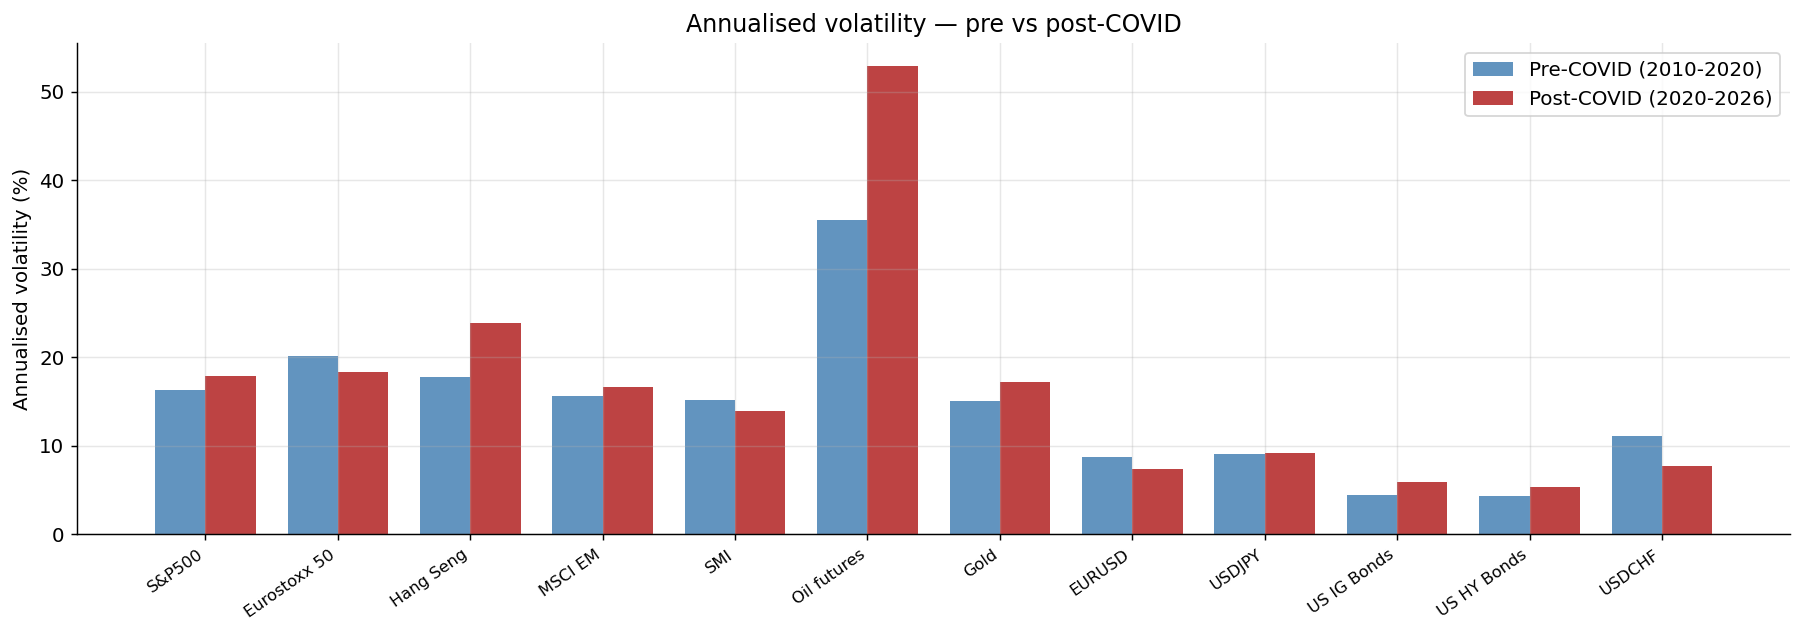

In [935]:
vol_pre  = ret_pre.std()  * np.sqrt(ANNUALIZATION) * 100
vol_post = ret_post.std() * np.sqrt(ANNUALIZATION) * 100

x     = np.arange(len(returns.columns))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, vol_pre,  width, label="Pre-COVID (2010-2020)",
       color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, vol_post, width, label="Post-COVID (2020-2026)",
       color=COLORS["post"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(returns.columns), rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Annualised volatility (%)")
ax.set_title("Annualised volatility — pre vs post-COVID")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_vol_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The chart reveals a mixed picture across asset classes. Equities show a modest increase in volatility post-COVID, with the Hang Seng standing out as the most affected. Oil futures display the largest shift, reflecting the structural disruption in energy markets that began with the April 2020 price collapse and continued with the geopolitical shocks of 2022. Credit markets tell a different story: US IG Bonds and US HY Bonds show a slight increase in volatility, consistent with the rate hiking cycle that followed the post-COVID inflation surge. FX volatility has been relatively stable, with USDCHF showing a decrease as the SNB flash crash of 2015 no longer distorts the post-COVID sample. Overall, the heterogeneity across asset classes suggests that COVID-19 did not affect all markets equally, a finding that will be explored more formally in the sections that follow.

## Section 1 — Stylized facts

Before estimating any model, we document that the return series exhibit the classical properties of financial data and test whether these properties have changed between the two periods. This gives a model-free first answer to the research question and motivates the GARCH estimation in Section 2.

### 1.1 Autocorrelation structure

Raw returns should have little autocorrelation if markets are approximately efficient. Squared returns, however, should display significant positive autocorrelation if volatility clustering is present — this is the core empirical motivation for ARCH-type models, first documented by Engle (1982). We compute the autocorrelation function of both series for the S&P 500 and compare the pre-COVID and post-COVID periods. A persistent ACF of squared returns confirms the presence of volatility clustering and justifies the use of GARCH models in the next section.

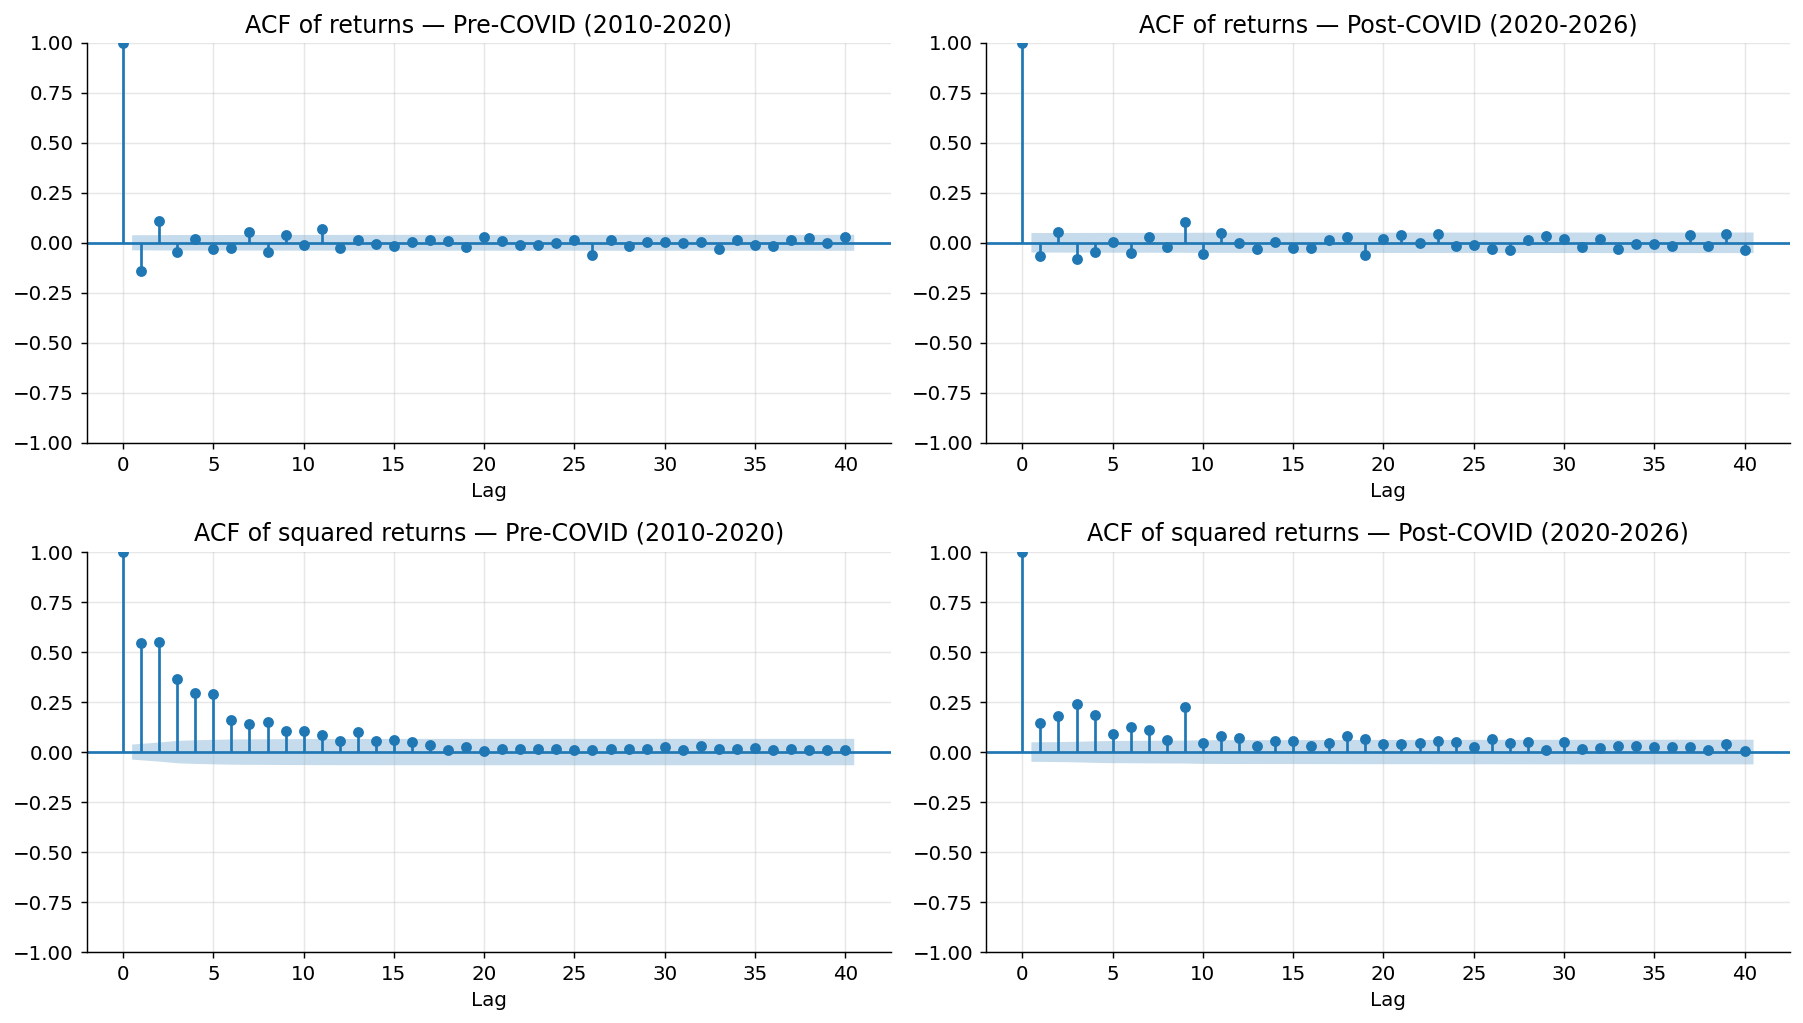

In [936]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

periods = {
    "Pre-COVID (2010-2020)" : ret_pre,
    "Post-COVID (2020-2026)": ret_post
}

for col, (label, ret) in enumerate(periods.items()):
    series    = ret["S&P500"].dropna()
    series_sq = series ** 2

    plot_acf(series,    lags=40, ax=axes[0, col],
             title=f"ACF of returns — {label}", alpha=0.05)
    plot_acf(series_sq, lags=40, ax=axes[1, col],
             title=f"ACF of squared returns — {label}", alpha=0.05)

    for ax in axes[:, col]:
        ax.set_xlabel("Lag")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_acf.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Formal tests for ARCH effects

Visual inspection of the ACF is useful but not sufficient. We complement it with two formal tests applied to all 12 assets in both periods. The Ljung-Box test checks whether squared returns are autocorrelated. The ARCH-LM test is a Lagrange multiplier test that explicitly tests the null hypothesis of no conditional heteroskedasticity. Rejecting the null on both tests confirms that volatility clustering is present and that a constant variance model would be misspecified.

In [937]:
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

results = []
for asset in returns.columns:
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series = ret[asset].dropna()
        lb     = acorr_ljungbox(series**2, lags=[10], return_df=True)
        lm     = het_arch(series, nlags=10)
        results.append({
            "Asset"           : asset,
            "Period"          : label,
            "LB stat"         : round(lb["lb_stat"].values[0], 2),
            "LB p-value"      : round(lb["lb_pvalue"].values[0], 4),
            "ARCH-LM stat"    : round(lm[0], 2),
            "ARCH-LM p-value" : round(lm[1], 4)
        })

tests_df = pd.DataFrame(results).set_index(["Asset", "Period"])
tests_df.to_csv(TAB_DIR / "tab1_arch_tests.csv")
tests_df

LB stat  LB p-value  ARCH-LM stat  ARCH-LM p-value
Asset        Period                                                        
S&P500       Pre-COVID   2696.97       0.000       1176.87           0.0000
             Post-COVID   387.56       0.000        242.97           0.0000
Eurostoxx 50 Pre-COVID    527.58       0.000        323.15           0.0000
             Post-COVID   284.40       0.000        183.73           0.0000
Hang Seng    Pre-COVID    413.67       0.000        224.92           0.0000
             Post-COVID    49.82       0.000         33.50           0.0002
MSCI EM      Pre-COVID    978.61       0.000        512.31           0.0000
             Post-COVID   139.07       0.000         59.96           0.0000
SMI          Pre-COVID    539.58       0.000        302.15           0.0000
             Post-COVID   501.14       0.000        265.69           0.0000
Oil futures  Pre-COVID   1178.71       0.000       1166.67           0.0000
             Post-COVID   308.67       0.000        203.37           0.0000
Gold         Pre-COVID    161.94       0.000        113.85           0.0000
             Post-COVID   406.47       0.000        251.01           0.0000
EURUSD       Pre-COVID    265.68       0.000        143.82           0.0000
             Post-COVID   181.34       0.000        100.06           0.0000
USDJPY       Pre-COVID    188.42       0.000        116.45           0.0000
             Post-COVID    65.98       0.000         43.65           0.0000
US IG Bonds  Pre-COVID   1168.56       0.000       1339.96           0.0000
             Post-COVID   165.39       0.000         76.25           0.0000
US HY Bonds  Pre-COVID   2001.25       0.000       1521.33           0.0000
             Post-COVID   553.66       0.000        349.70           0.0000
USDCHF       Pre-COVID      2.84       0.985          2.74           0.9869
             Post-COVID   137.72       0.000        109.61           0.0000

### 1.3 Excess kurtosis across assets and periods

Excess kurtosis measures how much fatter the tails of the empirical distribution are relative to a Gaussian. A value above zero indicates more frequent extreme events than a normal distribution would predict. We compare excess kurtosis across all 12 assets and both periods. Returns are winsorised at ±4 standard deviations before computing kurtosis to neutralise the effect of two isolated events: the SNB flash crash of January 2015 on USDCHF and the negative oil futures prices of April 2020. This winsorisation is applied only here and does not affect the data used in any other section.

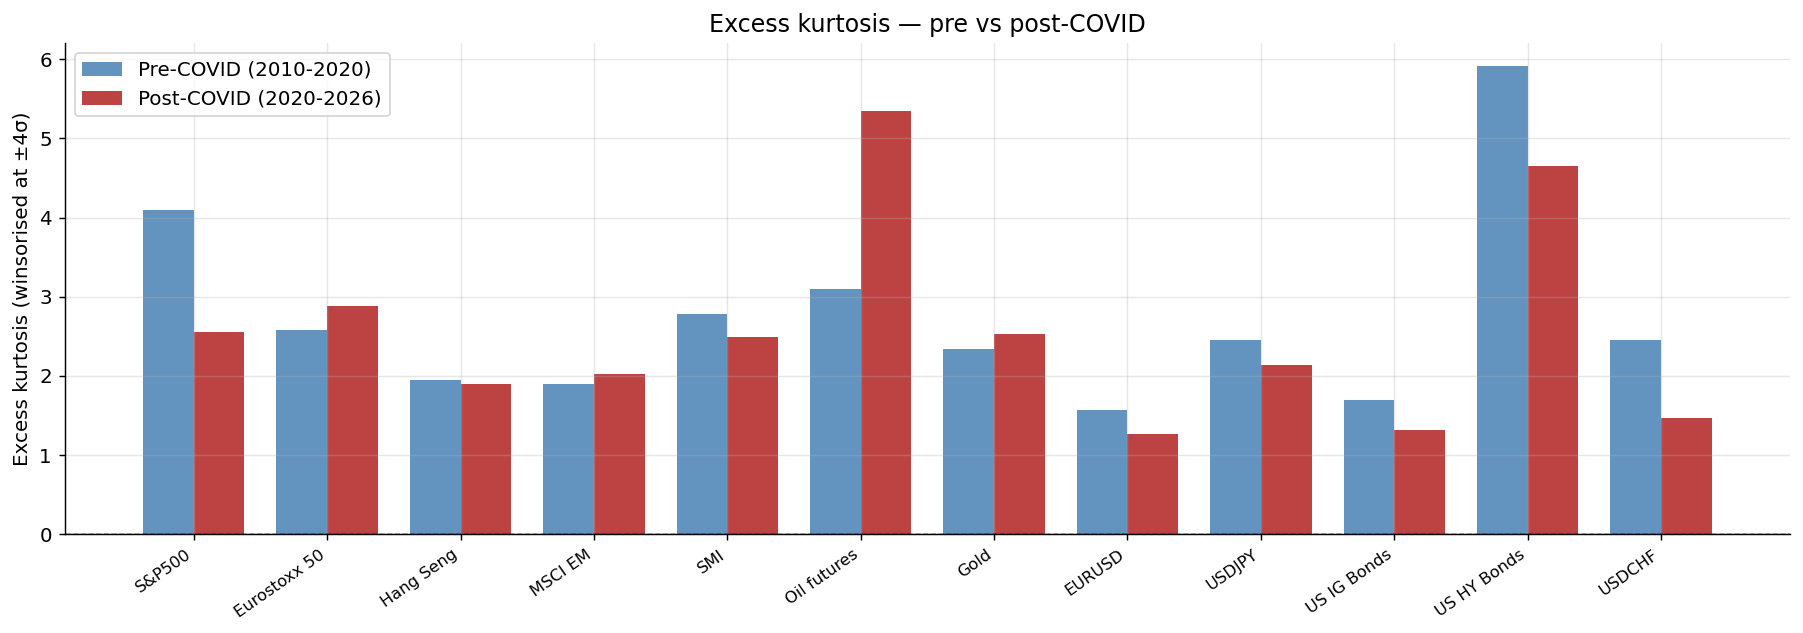

In [938]:
def winsorised_kurtosis(series, threshold=4):
    mu      = series.mean()
    sigma   = series.std()
    clipped = series.clip(lower=mu - threshold * sigma,
                          upper=mu + threshold * sigma)
    return stats.kurtosis(clipped)

kurt_pre  = ret_pre.apply(winsorised_kurtosis)
kurt_post = ret_post.apply(winsorised_kurtosis)

kurt_df = pd.DataFrame({
    "Pre-COVID (2010-2020)" : kurt_pre,
    "Post-COVID (2020-2026)": kurt_post
})

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(kurt_df))
width = 0.38

ax.bar(x - width/2, kurt_df["Pre-COVID (2010-2020)"],  width,
       label="Pre-COVID (2010-2020)",  color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, kurt_df["Post-COVID (2020-2026)"], width,
       label="Post-COVID (2020-2026)", color=COLORS["post"], alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(kurt_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Excess kurtosis (winsorised at ±4σ)")
ax.set_title("Excess kurtosis — pre vs post-COVID")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_kurtosis.png", dpi=150, bbox_inches="tight")
plt.show()

kurt_df.round(3).to_csv(TAB_DIR / "tab1_kurtosis.csv")

### 1.4 Summary — have the stylized facts changed?

The following table brings together the key measures for each asset: the first-lag autocorrelation of squared returns as a measure of volatility persistence, excess kurtosis as a measure of tail thickness, and the ARCH-LM p-value as a formal test of conditional heteroskedasticity. Reading across the two periods gives a direct answer to the question of whether the statistical properties of returns have changed since COVID-19.

In [939]:
summary = []

for asset in returns.columns:
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series    = ret[asset].dropna()
        series_sq = series ** 2

        acf1      = series_sq.autocorr(lag=1)
        kurt      = winsorised_kurtosis(series)
        lm        = het_arch(series, nlags=10)

        summary.append({
            "Asset"          : asset,
            "Period"         : label,
            "ACF(1) r²"      : round(acf1, 3),
            "Kurtosis"       : round(kurt, 3),
            "ARCH-LM p-value": round(lm[1], 4)
        })

summary_df = pd.DataFrame(summary).set_index(["Asset", "Period"])
summary_df.to_csv(TAB_DIR / "tab1_summary.csv")
summary_df

ACF(1) r²  Kurtosis  ARCH-LM p-value
Asset        Period                                          
S&P500       Pre-COVID       0.546     4.096           0.0000
             Post-COVID      0.144     2.552           0.0000
Eurostoxx 50 Pre-COVID       0.105     2.580           0.0000
             Post-COVID      0.144     2.882           0.0000
Hang Seng    Pre-COVID       0.103     1.943           0.0000
             Post-COVID      0.085     1.901           0.0002
MSCI EM      Pre-COVID       0.135     1.893           0.0000
             Post-COVID      0.202     2.019           0.0000
SMI          Pre-COVID       0.232     2.785           0.0000
             Post-COVID      0.475     2.497           0.0000
Oil futures  Pre-COVID       0.376     3.092           0.0000
             Post-COVID      0.266     5.348           0.0000
Gold         Pre-COVID       0.167     2.337           0.0000
             Post-COVID      0.103     2.533           0.0000
EURUSD       Pre-COVID       0.130     1.571           0.0000
             Post-COVID      0.148     1.268           0.0000
USDJPY       Pre-COVID       0.134     2.453           0.0000
             Post-COVID      0.082     2.142           0.0000
US IG Bonds  Pre-COVID       0.481     1.694           0.0000
             Post-COVID      0.177     1.320           0.0000
US HY Bonds  Pre-COVID       0.230     5.912           0.0000
             Post-COVID      0.245     4.654           0.0000
USDCHF       Pre-COVID       0.013     2.458           0.9869
             Post-COVID      0.109     1.464           0.0000

Three conclusions emerge from this table. First, ARCH effects are present in virtually all assets and both periods — the null of no conditional heteroskedasticity is rejected at the 1% level in 23 out of 24 cases, with USDCHF pre-COVID being the only exception, consistent with its near-constant behaviour under the SNB peg. Second, volatility persistence as measured by the first-lag ACF of squared returns has declined for most assets post-COVID — most notably for S&P 500 (0.546 to 0.144) and US IG Bonds (0.481 to 0.177). This suggests that volatility shocks resolve more quickly in the post-COVID regime. Third, excess kurtosis remains positive across all assets and periods, confirming that the Gaussian assumption is inappropriate and motivating the Student-t GARCH specification we consider in Section 2.

## Section 2 — GARCH models

The stylized facts documented in Section 1 confirm that volatility is time-varying and persistent across all assets. We now model this conditional volatility explicitly using GARCH(1,1) models estimated separately on the pre-COVID and post-COVID periods. The objective is to test whether the parameters of the volatility process — and in particular its persistence — have changed since COVID-19.

### 2.1 The GARCH(1,1) model

The GARCH(1,1) model of Bollerslev (1986) specifies the conditional variance as:

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

where $\varepsilon_t = r_t - \mu$ is the demeaned return, $\omega > 0$ is the long-run variance intercept, $\alpha \geq 0$ measures the reaction of volatility to recent shocks, and $\beta \geq 0$ measures the persistence of volatility. The sum $\alpha + \beta$ is the key parameter: when it is close to 1, shocks to volatility are highly persistent and decay slowly. When it is below 1, the process is covariance-stationary and volatility mean-reverts to its unconditional level $\omega / (1 - \alpha - \beta)$.

The model is estimated by Gaussian quasi-maximum likelihood. The log-likelihood for a sample of $T$ observations is:

$$\ell(\theta) = -\frac{1}{2} \sum_{t=1}^{T} \left( \log \sigma^2_t + \frac{\varepsilon^2_t}{\sigma^2_t} \right)$$

We initialise the variance recursion at the sample variance of the returns.

In [940]:
from scipy.optimize import minimize, differential_evolution

def garch_recursion(params, eps):
    omega, alpha, beta = params
    T         = len(eps)
    sigma2    = np.empty(T)
    sigma2[0] = np.var(eps)
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
    return sigma2

def garch_loglik(params, eps):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = garch_recursion(params, eps)
    if np.any(sigma2 <= 0):
        return 1e10
    return 0.5 * np.sum(np.log(sigma2) + eps**2 / sigma2)

def fit_garch(series):
    eps  = (series - series.mean()).values
    var0 = np.var(eps)

    bounds_de = [(1e-8, var0), (1e-6, 0.4), (0.5, 0.9999)]
    result_de = differential_evolution(
        garch_loglik, bounds_de, args=(eps,),
        seed=42, maxiter=1000, tol=1e-10,
        popsize=15, mutation=(0.5, 1), recombination=0.7
    )

    starts = [
        result_de.x,
        [var0 * 0.05, 0.10, 0.85],
        [var0 * 0.02, 0.05, 0.92],
        [var0 * 0.01, 0.15, 0.80],
        [var0 * 0.03, 0.20, 0.75],
    ]

    bounds_lbfgs = [(1e-8, None), (1e-6, 0.4), (1e-6, 0.9999)]
    best_result  = None
    best_val     = 1e10

    for s in starts:
        if s[1] + s[2] >= 1:
            continue
        res = minimize(
            garch_loglik, s, args=(eps,),
            method="L-BFGS-B", bounds=bounds_lbfgs,
            options={"maxiter": 5000, "ftol": 1e-14, "gtol": 1e-10}
        )
        if res.fun < best_val:
            best_val    = res.fun
            best_result = res

    omega, alpha, beta = best_result.x
    return {
        "omega"      : omega,
        "alpha"      : alpha,
        "beta"       : beta,
        "persistence": alpha + beta,
        "sigma2"     : garch_recursion(best_result.x, eps),
        "eps"        : eps,
        "success"    : best_result.success
    }

print("GARCH functions defined.")

GARCH functions defined.


### 2.2 Conditional volatility 

We apply the GARCH(1,1) model to the full sample for four representative assets, one per asset class: S&P 500 for equities, US IG Bonds for credit, Gold for commodities, and Oil futures to illustrate the extreme volatility episode of April 2020. The COVID shock of March 2020 is visible as a sharp spike in conditional volatility across all asset classes, comparable in magnitude to the Global Financial Crisis of 2008–2009 for equities and credit. What is interesting is not the spike itself but what happens after: does volatility revert to its pre-COVID level, or does it settle at a structurally different baseline? The parameter comparison in sections 2.3 and 2.4 will answer this question formally.

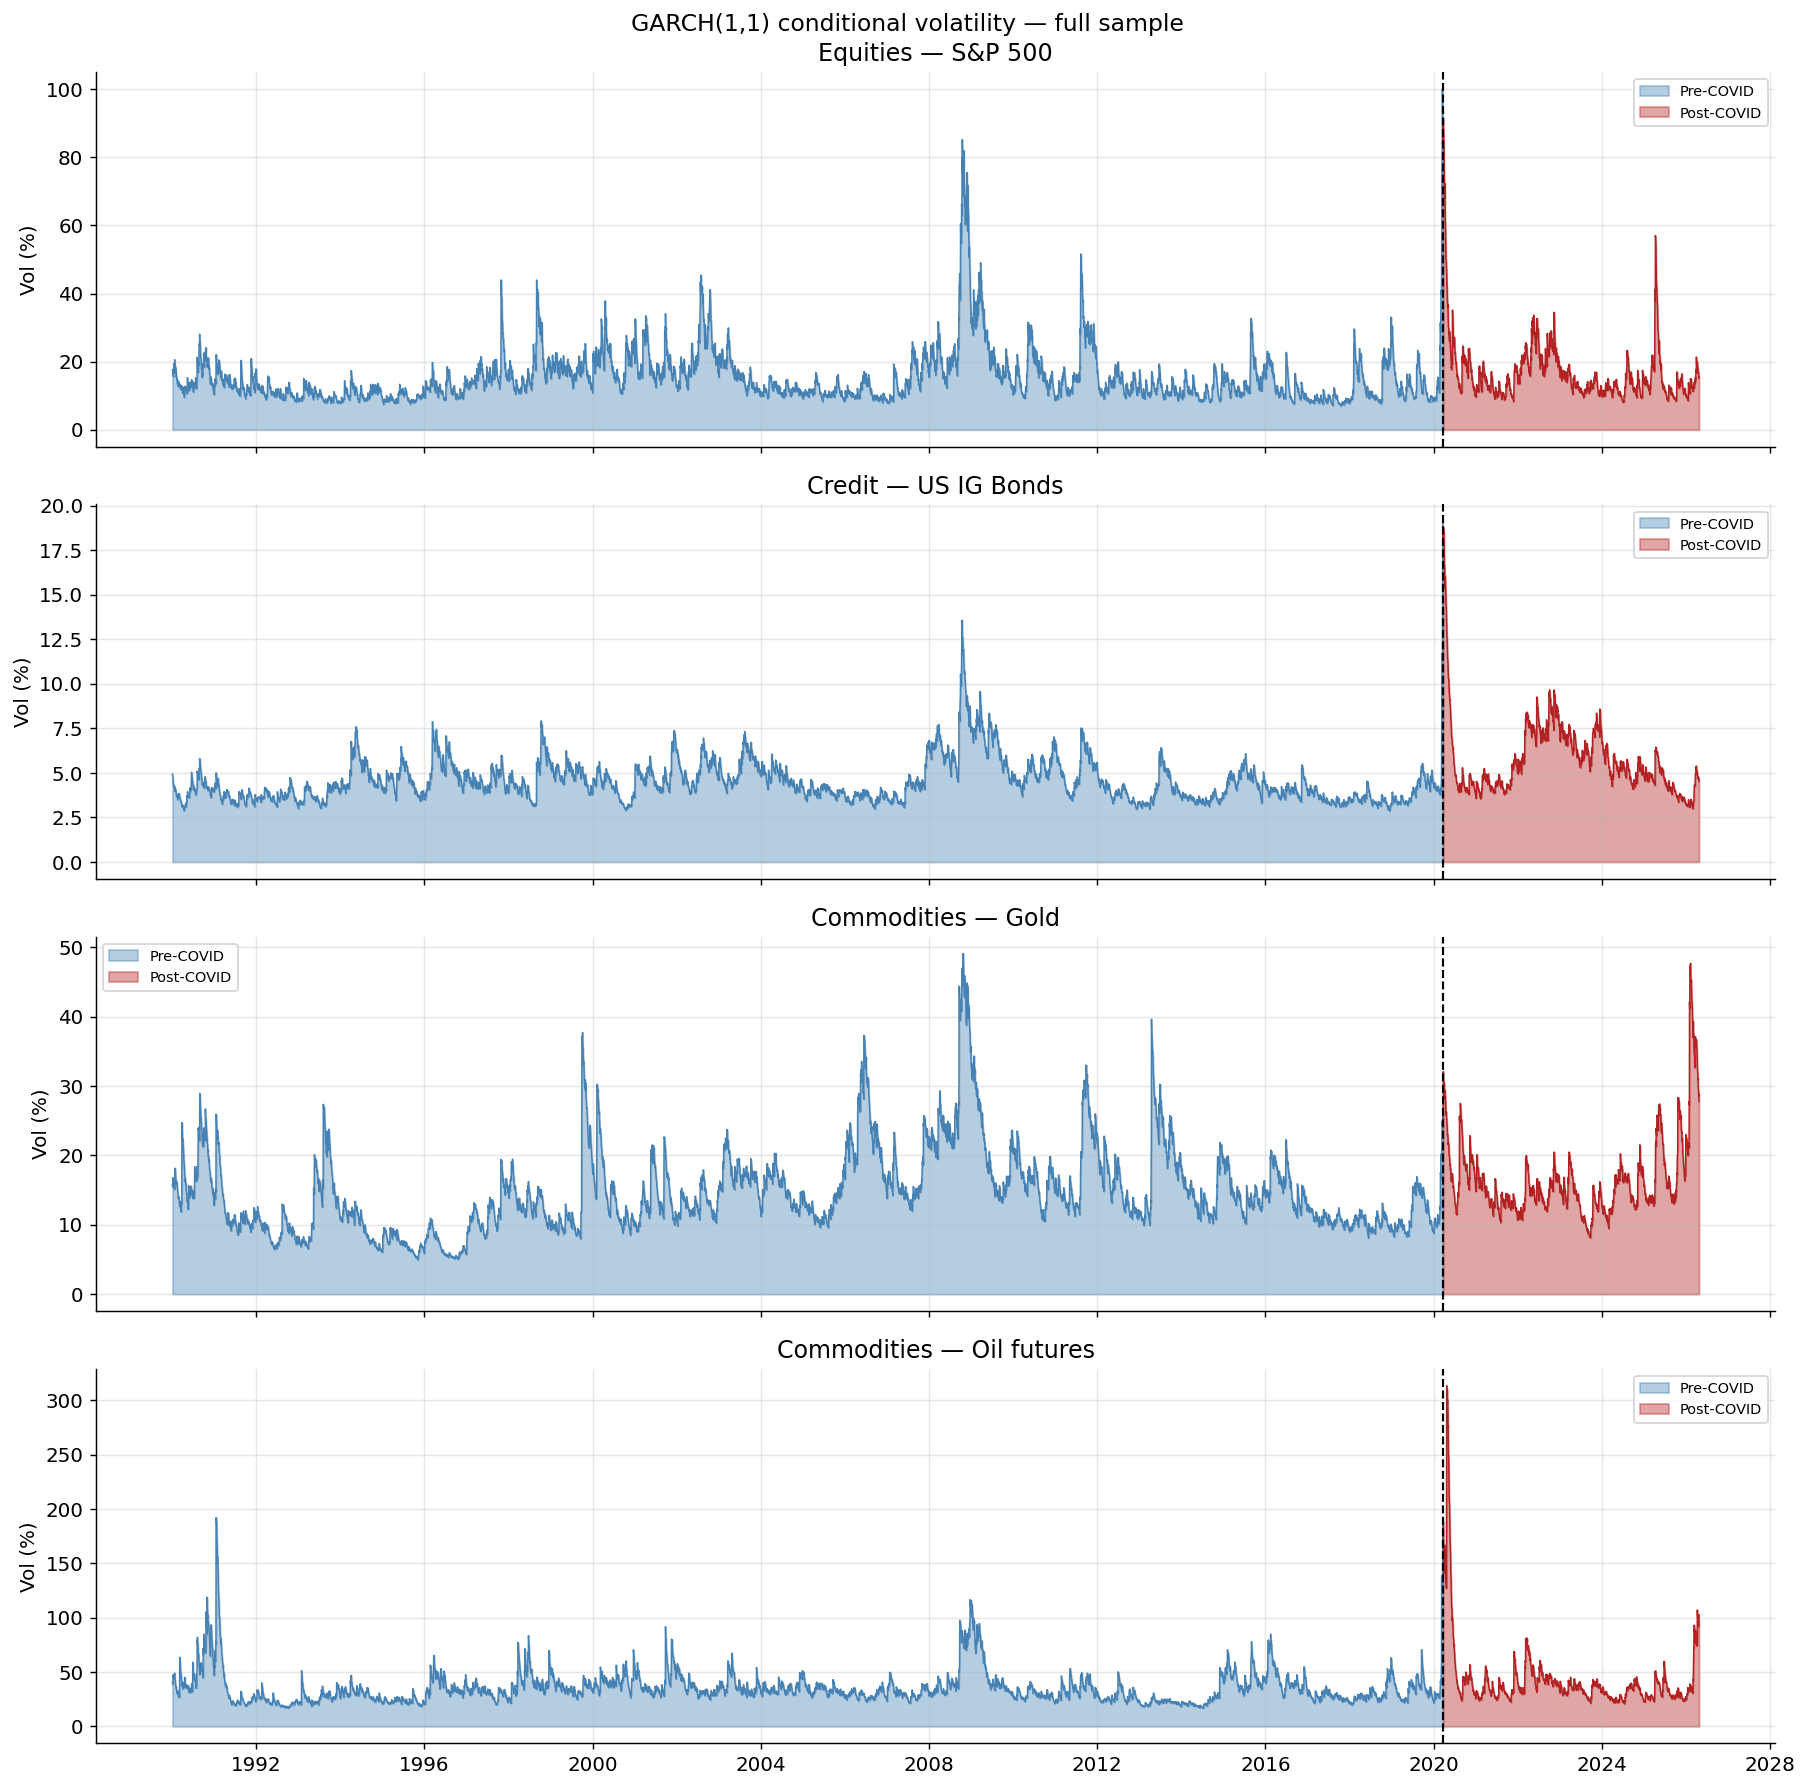

In [941]:
assets_plot = ["S&P500", "US IG Bonds", "Gold", "Oil futures"]
labels_plot = ["Equities — S&P 500", "Credit — US IG Bonds",
               "Commodities — Gold", "Commodities — Oil futures"]

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, asset, label in zip(axes, assets_plot, labels_plot):
    series    = returns[asset].dropna()
    garch_fit = fit_garch(series)
    vol       = pd.Series(
        np.sqrt(garch_fit["sigma2"]) * np.sqrt(ANNUALIZATION) * 100,
        index=series.index
    )

    vol_pre_plot  = vol[vol.index <  COVID_BREAK]
    vol_post_plot = vol[vol.index >= COVID_BREAK]

    ax.fill_between(vol_pre_plot.index,  vol_pre_plot,  alpha=0.4,
                    color=COLORS["pre"],  label="Pre-COVID")
    ax.fill_between(vol_post_plot.index, vol_post_plot, alpha=0.4,
                    color=COLORS["post"], label="Post-COVID")
    ax.plot(vol_pre_plot,  linewidth=0.8, color=COLORS["pre"])
    ax.plot(vol_post_plot, linewidth=0.8, color=COLORS["post"])
    ax.axvline(pd.Timestamp(COVID_BREAK), color="black",
               linestyle="--", linewidth=1.2)
    ax.set_title(label)
    ax.set_ylabel("Vol (%)")
    ax.legend(fontsize=8)

fig.suptitle("GARCH(1,1) conditional volatility — full sample", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_garch_vol.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 GARCH parameters — pre vs post-COVID

We estimate GARCH(1,1) models separately on the pre-COVID and post-COVID samples for all 12 assets. The parameter comparison across periods directly addresses the research question: if $\alpha$, $\beta$ or their sum have changed significantly, the volatility process itself has changed. A decrease in persistence post-COVID would suggest that volatility shocks dissipate faster in the new regime. An increase would suggest the opposite.

In [942]:
garch_results = []

for asset in returns.columns:
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series = ret[asset].dropna()
        g      = fit_garch(series)
        garch_results.append({
            "Asset"      : asset,
            "Period"     : label,
            "omega"      : round(g["omega"] * 1e4, 4),
            "alpha"      : round(g["alpha"], 4),
            "beta"       : round(g["beta"],  4),
            "alpha+beta" : round(g["persistence"], 4),
        })

garch_df = pd.DataFrame(garch_results).set_index(["Asset", "Period"])
garch_df.to_csv(TAB_DIR / "tab2_garch_params.csv")
garch_df

omega   alpha    beta  alpha+beta
Asset        Period                                        
S&P500       Pre-COVID   0.0347  0.1714  0.7951      0.9665
             Post-COVID  0.0438  0.1309  0.8333      0.9641
Eurostoxx 50 Pre-COVID   0.0320  0.1070  0.8770      0.9840
             Post-COVID  0.0831  0.1714  0.7721      0.9435
Hang Seng    Pre-COVID   0.0196  0.0470  0.9374      0.9845
             Post-COVID  0.0640  0.0613  0.9114      0.9727
MSCI EM      Pre-COVID   0.0191  0.0886  0.8934      0.9821
             Post-COVID  0.1047  0.1668  0.7423      0.9091
SMI          Pre-COVID   0.0456  0.1447  0.8066      0.9513
             Post-COVID  0.0642  0.1514  0.7603      0.9117
Oil futures  Pre-COVID   0.0394  0.0799  0.9183      0.9982
             Post-COVID  0.1559  0.1345  0.8574      0.9919
Gold         Pre-COVID   0.0115  0.0465  0.9417      0.9882
             Post-COVID  0.0685  0.1138  0.8251      0.9390
EURUSD       Pre-COVID   0.0011  0.0362  0.9610      0.9972
             Post-COVID  0.0032  0.0486  0.9360      0.9846
USDJPY       Pre-COVID   0.0032  0.0555  0.9378      0.9933
             Post-COVID  0.0020  0.0366  0.9577      0.9943
US IG Bonds  Pre-COVID   0.0010  0.0542  0.9340      0.9883
             Post-COVID  0.0009  0.0436  0.9490      0.9926
US HY Bonds  Pre-COVID   0.0016  0.2752  0.7248      1.0000
             Post-COVID  0.0008  0.1271  0.8703      0.9974
USDCHF       Pre-COVID   0.0060  0.0423  0.9577      1.0000
             Post-COVID  0.0396  0.1048  0.7258      0.8306

### 2.4 Persistence of volatility — pre vs post-COVID

The persistence parameter $\alpha + \beta$ is the single most informative statistic from the GARCH estimation. It measures how long a volatility shock takes to dissipate. A value close to 1 means shocks are long-lasting; a value well below 1 means volatility reverts quickly to its unconditional level. The following chart compares persistence across all 12 assets between the two periods.

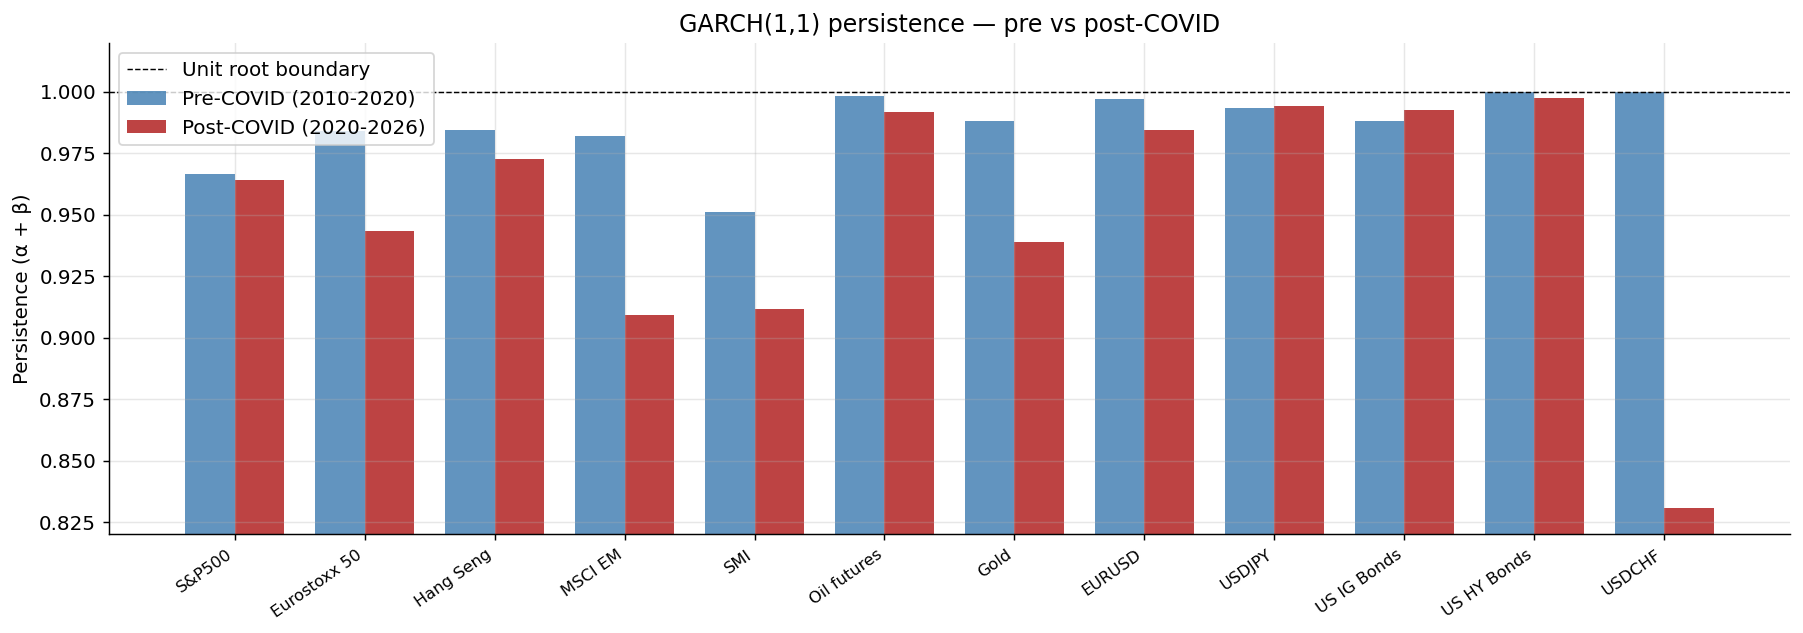

In [945]:
persistence_pre  = garch_df.xs("Pre-COVID",  level="Period")["alpha+beta"]
persistence_post = garch_df.xs("Post-COVID", level="Period")["alpha+beta"]

x     = np.arange(len(persistence_pre))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, persistence_pre,  width, label="Pre-COVID (2010-2020)",
       color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, persistence_post, width, label="Post-COVID (2020-2026)",
       color=COLORS["post"], alpha=0.85)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--", label="Unit root boundary")
ax.set_xticks(x)
ax.set_xticklabels(persistence_pre.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Persistence (α + β)")
ax.set_title("GARCH(1,1) persistence — pre vs post-COVID")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_ylim(0.82, 1.02)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_garch_persistence.png", dpi=150, bbox_inches="tight")
plt.show()

The persistence parameter has decreased post-COVID for 10 out of 12 assets, which is the central finding of this section. The most pronounced declines are observed for MSCI EM (0.982 to 0.909), SMI (0.951 to 0.912), Gold (0.988 to 0.939) and Eurostoxx 50 (0.984 to 0.944). This means that volatility shocks dissipate faster in the post-COVID regime than they did during the low-volatility decade of 2010-2020. Two exceptions stand out: USDJPY and US IG Bonds, where persistence has slightly increased, reflecting the persistent repricing of interest rate risk in bond markets following the inflation shock of 2021-2022. US HY Bonds and USDCHF show persistence at or near 1.0 in the pre-COVID period, consistent with near-integrated volatility dynamics during the SNB peg era and the credit spread compression of the 2010s.